# Лабораторная работа 2. Нейронные сети и компьютерное зрение.

Результатом лабораторной работы является отчет. Мы предпочитаем принимать отчеты в формате ноутбуков IPython (ipynb-файл). Постарайтесь сделать ваш отчет интересным рассказом, последовательно отвечающим на вопросы из заданий. Помимо ответов на вопросы, в отчете также должен быть код, однако чем меньше кода, тем лучше всем: нам — меньше проверять, вам — проще найти ошибку или дополнить эксперимент. При проверке оценивается четкость ответов на вопросы, аккуратность отчета и кода.

Мы уверены, что выполнение лабораторных работ занимает значительное время, поэтому не рекомендуем оставлять их на последний вечер перед сдачей.

# Часть 2. Fine-tuning обученных нейросетей (9.5 баллов + бонусные)

В этой части задания вам предстоит поработать с настоящими монстрами: сетями с почти сотней слоёв и десятками миллионов параметров. Например, такими:

![img](https://cloud.google.com/static/tpu/docs/images/inceptionv3onc--oview.png)
<center>googlenet inception v3</center>

__Чем кормить такого монстра?__

Огромные нейросети обучаются на огромных массивах данных. В компьютерном зрении таких несколько, но самый популярный из них [ImageNet](http://image-net.org/). В этой выборке более миллиона изображений.

Задача этой сети состоит в классификации каждого изображения в один из 1000 классов. Вот они:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import torch

classes = pickle.load(open('classes.pkl','rb'))
print(classes[::100])

['tench, Tinca tinca', 'black swan, Cygnus atratus', 'Tibetan terrier, chrysanthemum dog', 'tiger beetle', "academic gown, academic robe, judge's robe", 'cliff dwelling', 'hook, claw', 'paper towel', 'slot, one-armed bandit', 'water tower']


## Зоопарк нейросетей

В пуполярных бибилотеках для содания нейросетей, кроме всего прочего, есть зоопарк предобученных нейросетей: [torchvision.models](https://pytorch.org/vision/stable/models.html) или [pytorch_image_models](https://github.com/huggingface/pytorch-image-models) для PyTorch. В этом задании мы предлагаем поработать с моделью `InceptionV3`.

**Внимание!**
InceptionV3 требует много памяти для работы. Если ваш ПК начинает зависать:
* закройте всё кроме jupyter и браузера с одной вкладкой;
* если не помогло, загрузите эту тетрадку в [google colab](https://colab.research.google.com/) и работайте там;
* замените `InceptionV3` на `MobileNet` или на `ResNet`. Однако в этом случае вам придётся исправить и предобработку картинок.

Выберите оптимальный для вас вариант, загрузите модель и начнем работу!

Функция ниже позволяет найти для заданного изображения топ10 классов по мнению InceptionV3.

In [2]:
from torchvision.transforms import ToTensor
preprocess_input = ToTensor()

In [3]:
from skimage.transform import resize


def predict_top10(img, model, preprocess_input):
    img = resize(img, (299, 299), mode='reflect')
    assert img.min() >= 0.0 and img.max() <= 1.0
    plt.imshow(img)
    plt.show()

    img_preprocessed: torch.Tensor = preprocess_input(img).unsqueeze(0).float()
    probs = model(img_preprocessed)[0]
    
    labels = torch.topk(probs, 10).indices
    print(labels)
    print('top-10 classes:')
    for l in labels:
        print('%.4f\t%s' % (probs.ravel()[l], classes[l].split(',')[0]))

In [4]:
from torchvision.models import inception_v3
model = inception_v3()
model.eval()

/home/tseshnatijma/ml_venv/lib/python3.10/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

В PyTorch все преобрзаования над картинкой производятся при момощи модуля `torchvision.transform`, для преобразования в тензор используется класс `torchvision.transform.ToTensor`. Обратите внимание, что, в отличие от Tensorflow, родной входной формат для PyTorch - это значения в диапазоне $[0; 1]$.

Проверим, как она работает на близкой к обучающей выборке картинке:

In [6]:
# predict_top10(plt.imread('albatross.jpg'), model, preprocess_input)

А теперь попробуем ее на чем-то неожиданном!

--2026-03-15 19:52:05--  http://cdn.com.do/wp-content/uploads/2017/02/Donal-Trum-Derogar.jpeg
Resolving cdn.com.do (cdn.com.do)... 172.67.160.120, 104.21.42.94, 2606:4700:3031::6815:2a5e, ...
Connecting to cdn.com.do (cdn.com.do)|172.67.160.120|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://cdn.com.do/wp-content/uploads/2017/02/Donal-Trum-Derogar.jpeg [following]
--2026-03-15 19:52:05--  https://cdn.com.do/wp-content/uploads/2017/02/Donal-Trum-Derogar.jpeg
Connecting to cdn.com.do (cdn.com.do)|172.67.160.120|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 51048 (50K) [image/jpeg]
Saving to: ‘img.jpg’

img.jpg             100%[===================>]  49.85K  --.-KB/s    in 0.004s  

2026-03-15 19:52:05 (11.6 MB/s) - ‘img.jpg’ saved [51048/51048]



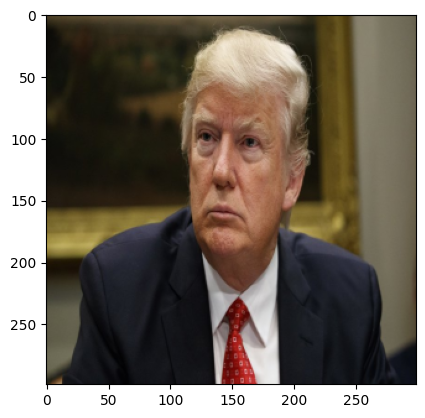

tensor([725, 729, 795, 160, 930, 529, 950, 100, 834, 555])
top-10 classes:
527689646080.0000	pitcher
496443097088.0000	plate rack
470691643392.0000	ski
467750551552.0000	Afghan hound
465683742720.0000	French loaf
432192946176.0000	diaper
427045322752.0000	orange
425149038592.0000	black swan
410527137792.0000	suit
408662933504.0000	fire engine


/tmp/ipykernel_561838/29450272.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('%.4f\t%s' % (probs.ravel()[l], classes[l].split(',')[0]))


In [5]:
!wget http://cdn.com.do/wp-content/uploads/2017/02/Donal-Trum-Derogar.jpeg -O img.jpg

img = plt.imread('img.jpg')
predict_top10(img, model, preprocess_input)

## Dogs Vs Cats

А теперь попробуем построить классификатор, который отличает изображение кошки от собаки. 

![img](https://dingo.care2.com/pictures/greenliving/1203/1202163.large.jpg)

Загрузите данные с [яндекс-диска](https://disk.yandex.ru/d/7Fgf7HU4w4An-A)

In [38]:
import os
import torch.nn.functional as F

from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torch import nn
from collections import OrderedDict
from torchvision.models import Inception_V3_Weights
from torch.utils.tensorboard import SummaryWriter
from tqdm import trange

data_cats_dogs_dir = "/home/tseshnatijma/data/cats_dogs_train"
data_root_dir = "/home/tseshnatijma/data"
models_root_dit = "/home/tseshnatijma/models"

In [7]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [8]:
class DogCatDataset(Dataset):
    def __init__(self, root_dir: str, transform=None):
        super().__init__()
        self.root_dir = root_dir
        self.transform = transform
        
        self.samples_paths: list[(str, str)] = []
        self.class_to_idx: dict[str, int] = { "cat": 1, "dog": 0}
        
        
        for img_path in sorted(os.listdir(root_dir)):
            label, _, _ = img_path.split('.')            
            self.samples_paths.append((img_path, label))
    
    def __len__(self):
        return len(self.samples_paths)
    
    def __getitem__(self, index):
        img_path, label = self.samples_paths[index]
        
        image = Image.open(self.root_dir + '/' + img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        # print(type(image), image.device)

        
        return image, self.class_to_idx[label]


## Sklearn way

**Задание 1 (2.5 балла).** В вашем распоряжении есть предобученная сеть InceptionV3. Ваша задача — обучить классификатор из sklearn (на ваш выбор), который будет отличать котов от собак, используя __активации нейронной сети в качестве признаков__.

Для начала прочитайте данные и сформируйте для вашего классификатора обучающую и тестовую выборки в пропорции 4:1. 

В вашем распоряжении всего 25 000 изображений различного размера, все в формате JPEG. Изображения кошек имеют название вида `./train/cat.*.jpg`, собак — `./train/dog.*.jpg`.

Считайте данные и для каждой картинки вычислите признаки из промежуточного слоя свёрточной сети. В качестве признаков можно выбрать какой-нибудь слой или несколько слоёв сети. Попробуйте найти комбинацию слоёв, которая работает лучше всего.

[Здесь](https://keras.io/getting-started/faq/#how-can-i-obtain-the-output-of-an-intermediate-layer) можно почитать, как посчитать активацию промежуточных слоёв. В PyTorch это можно сделать при помощи [forward hooks](https://medium.com/the-owl/using-forward-hooks-to-extract-intermediate-layer-outputs-from-a-pre-trained-model-in-pytorch-1ec17af78712)

Разделите данные на обучение и тест в отношении 4:1.

In [9]:
inception_weights = Inception_V3_Weights.DEFAULT
process_input = inception_weights.transforms()

cat_dog_ds = DogCatDataset(data_cats_dogs_dir, process_input)
print(f"Ds len: {len(cat_dog_ds)}")

train_ds, test_ds = random_split(cat_dog_ds, lengths=(20_000, 5_000))
train_ds, val_ds = random_split(train_ds, lengths=(15_000, 5_000))
print(f"Train: {len(train_ds)}\nVal: {len(val_ds)}\nTest: {len(test_ds)}")


Ds len: 25000
Train: 15000
Val: 5000
Test: 5000


In [10]:
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=True, num_workers=2)
test_dl = DataLoader(test_ds, batch_size=64, shuffle=True, num_workers=2)

In [11]:
for i, k in enumerate(list(inception_v3()._modules.keys())):
    print(i, k) 

/home/tseshnatijma/ml_venv/lib/python3.10/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


0 Conv2d_1a_3x3
1 Conv2d_2a_3x3
2 Conv2d_2b_3x3
3 maxpool1
4 Conv2d_3b_1x1
5 Conv2d_4a_3x3
6 maxpool2
7 Mixed_5b
8 Mixed_5c
9 Mixed_5d
10 Mixed_6a
11 Mixed_6b
12 Mixed_6c
13 Mixed_6d
14 Mixed_6e
15 AuxLogits
16 Mixed_7a
17 Mixed_7b
18 Mixed_7c
19 avgpool
20 dropout
21 fc


Подготовим функции для сбора активаций для каждой картинки

In [12]:
class HookModel(nn.Module):
    def __init__(self, model, output_layers, *args):
        super().__init__(*args)
        self.output_layers = output_layers
        self.selected_out = OrderedDict()
        self.pretrained = model
        self.fhooks = []

        for i, l in enumerate(list(self.pretrained._modules.keys())):
            if i in self.output_layers:
                self.fhooks.append(getattr(self.pretrained, l).register_forward_hook(self.forward_hook(l)))
    
    def forward_hook(self, layer_name):
        def hook(module, input, output):
            self.selected_out[layer_name] = output
        return hook

    def forward(self, x):
        out = self.pretrained(x)
        return out, self.selected_out

In [13]:
def get_activation_featured_data(model_hook, img_dl: DataLoader):
    x_features = []
    targets = []
    
    for xb, yb in img_dl:
        targets.append(yb)
        _, layerout = model_hook(xb.to(device))
        xb_feature = []
        for _, v in layerout.items():
            xb_feature.append(v.detach().flatten(1))
        x_features.append(torch.cat(xb_feature, dim=1))
    
    return torch.cat(x_features, dim=0).cpu(), torch.cat(targets, dim=0).cpu()



In [14]:
def compute_and_save_features(model_hook, img_dl: DataLoader, path: str, n_samples: int, n_features: int):
    X = np.memmap(
        path,
        dtype="float32",
        mode="w+",
        shape=(n_samples, n_features)
    )
    
    targets = []
    bs = img_dl.batch_size
    bs_count = 0
    for xb, yb in img_dl:
        left = bs_count * bs
        right = (bs_count + 1) * bs
        
        
        targets.append(yb)
        _, layerout = model_hook(xb.to(device))
        xb_feature = []
        for _, v in layerout.items():
            xb_feature.append(v.detach().flatten(1))
        X[left:right, :] = torch.cat(xb_feature, dim=1).detach().cpu()
        bs_count += 1
    
    X.flush()
    return torch.cat(targets, dim=0).cpu()

Я выбрал 19ый слой, где всего 2048 фичей признаков, чего должно быть вполне достаточно для обучения LogReg 

In [ ]:
model_hook = HookModel(inception_v3(weights=inception_weights), output_layers=[19])
model_hook.eval()
model_hook.to(device)

y_train_f = compute_and_save_features(model_hook, train_dl, data_root_dir + "/X_train_f", 15_000, 2048)
y_val_f = compute_and_save_features(model_hook, val_dl, data_root_dir + "/X_val_f", 5_000, 2048)
y_test_f = compute_and_save_features(model_hook, test_dl, data_root_dir + "/X_test_f", 5_000, 2048)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /home/tseshnatijma/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 104M/104M [00:09<00:00, 11.5MB/s]
/tmp/ipykernel_2660988/465919547.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  X[left:right, :] = torch.cat(xb_feature, dim=1).detach().cpu()


In [15]:
X_train_f = np.memmap(
        data_root_dir + "/X_train_f",
        dtype="float32",
        mode="r",
        shape=(15_000, 2048)
    )

X_val_f = np.memmap(
        data_root_dir + "/X_val_f",
        dtype="float32",
        mode="r",
        shape=(5_000, 2048)
    )

X_test_f = np.memmap(
        data_root_dir + "/X_test_f",
        dtype="float32",
        mode="r",
        shape=(5_000, 2048)
    )

Обучите поверх этих признаков классификатор из sklearn (можно попробовать несколько и выбрать лучший). Попробуйте получить ROC-AUC __хотя бы 99%__.

In [15]:
from sklearn.metrics import roc_auc_score

In [22]:
x_train_mean = X_train_f.mean(axis=0)
x_train_std = X_train_f.std(axis=0)

In [23]:
X_train_f_norm = np.memmap(
    data_root_dir + "/X_train_f_norm",
    dtype="float32",
    mode="w+",
    shape=X_train_f.shape
)

X_val_f_norm = np.memmap(
    data_root_dir + "/X_val_f_norm",
    dtype="float32",
    mode="w+",
    shape=X_val_f.shape
)

X_test_f_norm = np.memmap(
    data_root_dir + "/X_test_f_norm",
    dtype="float32",
    mode="w+",
    shape=X_test_f.shape
)

In [24]:
eps = 1e-9
X_train_f_norm = (X_train_f - x_train_mean) / (x_train_std + eps)
X_val_f_norm = (X_val_f - x_train_mean) / (x_train_std + eps)
X_test_f_norm = (X_test_f - x_train_mean) / (x_train_std + eps)

In [25]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train_f_norm, y_train_f)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [26]:
roc_auc_score(y_test_f, log_reg.predict_proba(X_test_f_norm)[:, 1]), roc_auc_score(y_val_f, log_reg.predict_proba(X_val_f)[:, 1])

(0.9992650522672168, 0.9994019196172286)

Опишите ваши выводы о проделанной работе.

У меня получилось пробить порог, используя активации. Но перед этим я очень долго экспериментировал. Заработало всё только тогда, когда я догадался нормализовать данные...  
Из эксперимента выше, можно сделать вывод, что первая часть модели - именно свёрточные слои - выдают хорошие "эмбендинги"-признаки картинок, на которых можно уже учить более простую модель классификатор.

## Fine-tuning

**Задание 2 (4 балла).** Давайте попробуем добиться ещё большего качества через дообучение (fine-tuning) модели. Новая цель — получить качество лучше, чем у классификатора из предыдущего пункта на признаках `InceptionV3`. Цель этого задания: получить значение ROC-AUC __не меньше 99.5%__.

__Если посмотреть выше, качество у обычного LogReg уже выше 99.5%__

__Шаг 1.__  Постройте сеть, в которой InceptionV3 "без головы" используется в качестве первого слоя. Поверх неё надстройте новую голову из `torch.nn`— она будет отличать котов от собак. Это можно сделать с помощью общего интерфейса модели. В PyTorch несеквенциальные модели можно строить, наследуя модель от класса `torch.nn.Module`: [общий интерфейс модели PyTorch](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module)

In [16]:
class CatDogsImageClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.backbone = inception_v3(weights=Inception_V3_Weights)
        
        classifier_in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.head = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(classifier_in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, 2)
        )
    
    def forward(self, xb):
        features = self.backbone(xb)
        if self.training:
            features = features.logits
        return self.head(features)
    
    def predict_classes(self, xb):
        logits: torch.Tensor = self.forward(xb)
        return logits.argmax(dim=1)


__Шаг 2.__ Обучите "голову" на обучающей выборке, не меняя весов изначальной сети. Это называется обучением с замороженными весами. Как это сделать в Keras, можно прочитать [здесь](https://keras.io/getting-started/faq/#how-can-i-freeze-keras-layers), для PyTorch смотрите [статью](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html), подраздел про Finetuning. В PyTorch заморозка весов регулируется параметром `requires_grad = False`.

In [17]:
def loss_batch(model, loss_func, xb, yb, opt=None):
    loss = loss_func(model(xb), yb)
    
    if opt is not None:
        loss.backward()
        opt.step()
        opt.zero_grad()
    
    return loss.item(), xb.shape[0]
    

def fit(
    epochs: int,
    model: nn.Module,
    loss_func,
    opt,
    train_dl,
    valid_dl,
    writer,
    lr_scheduler = None,
    verbose: bool = False
):
    
    model = model.to(device)
    for epoch in trange(epochs):
        train_losses = []
        val_losses = []
        val_acc = 0
        
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            loss, b_size = loss_batch(model, loss_func, xb, yb, opt)
            train_losses.append(loss * b_size)
        
        model.eval()
        with torch.no_grad():
            correct = 0
            total_val = 0
            
            for xb, yb in valid_dl:
                xb, yb = xb.to(device), yb.to(device)
                
                loss, b_size = loss_batch(model, loss_func, xb, yb)
                val_losses.append(loss * b_size)
                
                correct += (model.predict_classes(xb) == yb).sum()
                total_val += b_size
            
                
        train_loss = float(torch.sum(torch.as_tensor(train_losses)) / len(train_dl))
        val_loss = float(torch.sum(torch.as_tensor(val_losses)) / len(valid_dl))
        val_acc = correct / total_val
        
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)
        writer.add_scalar("Acc/val", val_acc, epoch)
        
        if verbose:
            curr_lr = opt.param_groups[0]["lr"]
            print(f"Epoch: {epoch:03d} "
                f"Train_loss: {train_loss:.4f} "
                f"Val_loss: {val_loss:.4f} "
                f"Val_acc: {val_acc:.4f} "
                f"LR: {curr_lr:.2e}")
        
        if lr_scheduler:
            lr_scheduler.step(val_loss)
    
    writer.close()


In [18]:
print(len(train_dl.dataset.dataset.dataset.class_to_idx))
# print(train_dl.dataset.dataset.class_to_idx)

2


In [19]:
cat_dog_classifier = CatDogsImageClassifier()
for param in cat_dog_classifier.backbone.parameters():
    param.requires_grad  = False
opt = torch.optim.SGD(cat_dog_classifier.parameters(), lr=0.001, momentum=0.9)
writer = SummaryWriter("runs/fine_tuning/freeze_learning")

fit(15, cat_dog_classifier, F.cross_entropy, opt, train_dl, val_dl, writer, verbose=True)

/home/tseshnatijma/ml_venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
  7%|███████████▍                                                                                                                                                                | 1/15 [02:21<32:58, 141.31s/it]

Epoch: 000 Train_loss: 29.1439 Val_loss: 10.8179 Val_acc: 0.9676 LR: 1.00e-03


 13%|██████████████████████▉                                                                                                                                                     | 2/15 [03:42<22:54, 105.72s/it]

Epoch: 001 Train_loss: 13.3090 Val_loss: 6.2945 Val_acc: 0.9706 LR: 1.00e-03


 20%|██████████████████████████████████▌                                                                                                                                          | 3/15 [04:53<18:00, 90.02s/it]

...

Epoch: 012 Train_loss: 8.7740 Val_loss: 4.7170 Val_acc: 0.9722 LR: 1.00e-03


 93%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 14/15 [18:19<01:11, 71.59s/it]

Epoch: 013 Train_loss: 8.2382 Val_loss: 4.5258 Val_acc: 0.9730 LR: 1.00e-03


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [19:31<00:00, 78.10s/it]

Epoch: 014 Train_loss: 8.4141 Val_loss: 5.5316 Val_acc: 0.9674 LR: 1.00e-03


In [ ]:
y_probas = []
y_targets = []

cat_dog_classifier.eval()
for xb, yb in test_dl:
    logits = torch.nn.Sigmoid()(cat_dog_classifier(xb.to(device))).detach().cpu()
    
    y_probas.append(logits)
    y_targets.append(yb.detach().cpu())

In [33]:
y_probas = torch.cat(y_probas, dim=0)
y_targets = torch.cat(y_targets, dim=0)

In [36]:
roc_auc_score(y_targets, y_probas[:, 1])

0.9973869424906485

Модель выдала результаты чуть хуже, чем ЛогРег

__Sanity check:__ После этого шага ваша модель должна уже быть сравнима по точности с моделями из задания 1.

Если всё получилось, самое время [сохранить модель](https://pytorch.org/tutorials/beginner/saving_loading_models.html).

In [40]:
torch.save(cat_dog_classifier.state_dict(), models_root_dit + "/cat_dog_model.pt")

__Шаг 3.__ "Разморозьте" несколько предыдущих слоёв модели и продолжите обучение. На этом этапе важно не переобучиться: смотрите качество на валидации.

Если качество не улучшается, а сразу идёт вниз, попробуйте уменьшить число обучаемых слоёв или воспользуйтесь [аугментацией данных](https://keras.io/preprocessing/image/) ([аугментация](https://pytorch.org/vision/stable/transforms.html) в Pytorch). В общем случае всегда полезно помнить про аугментацию данных, даже если и без неё всё работает — иногда она творит [чудеса](https://medium.com/nanonets/how-to-use-deep-learning-when-you-have-limited-data-part-2-data-augmentation-c26971dc8ced).

Разморозим несколько слоёв:  
16 Mixed_7a  
17 Mixed_7b  
18 Mixed_7c  

Почему именно их?  
Если свёртки учатся находить линии (общие очертания) и другие геометрические фигуры на кратинки (именно первые слои свёрток), то логично дообучить именно последние слои свёрток, чтобы они могли лучше находить на картинке черты собаки/кошки.

In [48]:
for name, param in cat_dog_classifier.named_parameters():
    if "Mixed_7" in name:
        param.requires_grad = True

fit(20, cat_dog_classifier, F.cross_entropy, opt, train_dl, val_dl, writer, verbose=True)

  5%|████████▌                                                                                                                                                                   | 1/20 [01:42<32:21, 102.18s/it]

Epoch: 000 Train_loss: 5.3727 Val_loss: 3.0812 Val_acc: 0.9798 LR: 1.00e-03


 10%|█████████████████▎                                                                                                                                                           | 2/20 [03:05<27:16, 90.94s/it]

Epoch: 001 Train_loss: 3.0729 Val_loss: 2.6518 Val_acc: 0.9840 LR: 1.00e-03


 15%|█████████████████████████▉                                                                                                                                                   | 3/20 [04:29<24:50, 87.70s/it]

...

Epoch: 013 Train_loss: 0.1843 Val_loss: 3.3049 Val_acc: 0.9876 LR: 1.00e-03


 75%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                           | 15/20 [20:13<06:29, 77.83s/it]

Epoch: 014 Train_loss: 0.1652 Val_loss: 3.7564 Val_acc: 0.9868 LR: 1.00e-03


 75%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                                           | 15/20 [20:39<06:53, 82.63s/it]


KeyboardInterrupt: 

__Шаг 4.__ Вычислите финальное качество.

In [51]:
y_probas = []
y_targets = []

cat_dog_classifier.eval()
for xb, yb in test_dl:
    logits = torch.nn.Sigmoid()(cat_dog_classifier(xb.to(device))).detach().cpu()
    
    y_probas.append(logits)
    y_targets.append(yb.detach().cpu())

In [52]:
y_probas = torch.cat(y_probas, dim=0)
y_targets = torch.cat(y_targets, dim=0)

In [53]:
roc_auc_score(y_targets, y_probas[:, 1])

0.9990234043656482

In [54]:
torch.save(cat_dog_classifier.state_dict(), models_root_dit + "/cat_dog_model_2.pt")

Стало ещё чуть лучше, но почему то всё равно не дотягивает до обычной Логистической Регрессии

Напишите отчёт и вознаградите себя за старания чем-нибудь.

Учить нейронки было интересно.  
Единственное, непонятно, как сранивать такие маленькие изменения в мтерике, какую модель в итоге лучше выбрать? И почему ЛогРег показал такие высокие резльтаты

## Улучшение fine-tuning (3б + бонусные)

Попробуйте одну (обязательно) из следующих техник:

* Ансамбль из нескольких предобученных нейросетей. Bagging? Stacking? Boosting? [Усреднение весов моделей](https://arxiv.org/pdf/2203.05482v3.pdf)? Всё, что пожелаете.
* Более честный эксперимент: разделяем данные на train/__dev__/test, все сравнения делаем по dev, а test используем только в самом конце.
* Аугментировать данные картинками из интернета. Уж чего, а котиков и собачек там хватает.
* Примените подход к улучшению качества аугментации из статьи - [Изучение аугментации данных и как оно влияет на обучение](https://arxiv.org/pdf/1906.06423v4.pdf)

За каждую дополнительно рассмотренную технику можно получить также +2 балла. Можете рассмотреть что-то другое, например, подходы к обучению из второго семинара по нейронкам.

In [ ]:
#  Не успель(